In [23]:
import pymc as pm
from dataloader import samlet_df
import numpy as np
import arviz as az

$p(kass) = a\cdot dage + b\cdot vask$

# Weibull model

In [16]:
from scipy.stats import weibull_min

In [27]:
#finder rækker hvor dage=0 eller vask=0 
mask = (samlet_df['Dage i cirkulation'] == 0) | (samlet_df['Total antal vask'] == 0)
print(mask.sum(), 'ud af', len(samlet_df))

#fjerner dem fra df
samlet_df_filtered = samlet_df[~mask]

#sample en delmængde af dataen mens modellen udvikles
samlet_df_sample = samlet_df_filtered.sample(n=1000, random_state = 42)

21535 ud af 247265


In [33]:
alpha_est, _, beta_est = weibull_min.fit(samlet_df_filtered['Dage i cirkulation'], floc=0)
print(alpha_est, beta_est)

1.2859154024089614 1264.9788864156196


In [34]:
alpha_est, _, beta_est = weibull_min.fit(samlet_df_sample['Dage i cirkulation'], floc=0)
print(alpha_est, beta_est)

1.2843340360109643 1273.7289615170548


Vi tilføjer et intercept til $\beta$ for at sikre korrekt størrelsesorden:

$$\beta = e^{intercept + a \cdot vask_{norm}}$$

Vi vælger $intercept = \ln(\beta_{est})$, så $\beta \approx \beta_{est} \approx 1265$ ved gennemsnitlig vask ($vask_{norm} = 0$).

In [37]:
mean_dage = samlet_df['Dage i cirkulation'].mean()
mean_vask = samlet_df['Total antal vask'].mean()
#bruger normaliseret vask for at undgå ekstrem høje beta værdier
vask_norm = (samlet_df_sample['Total antal vask'] - mean_vask) / samlet_df_sample['Total antal vask'].std()

with pm.Model() as model:
    #priors
    alpha = pm.Gamma('alpha',mu = alpha_est, sigma=0.5)
    intercept = pm.Normal('intercept', mu=np.log(beta_est), sigma=1)
    a = pm.HalfNormal('a', sigma=1) #halfnormal er normalfordelingen med afskæring i 0. Kun højre side

    #deterministisk funktion af a og observerede data
    beta = pm.math.exp(intercept + a * vask_norm)

    #likelihood
    obs = pm.Weibull('obs', alpha = alpha, beta = beta, observed = samlet_df_sample['Dage i cirkulation'])
    
    #resultat
    trace = pm.sample(draws=500, tune=500, chains=2)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [alpha, intercept, a]


Output()

Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 405 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


In [38]:
az.summary(trace)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
intercept,7.079,0.024,7.035,7.123,0.001,0.001,916.0,729.0,1.0
alpha,1.371,0.034,1.310,1.435,0.001,0.001,943.0,654.0,1.0
a,0.303,0.023,0.260,0.346,0.001,0.001,1612.0,924.0,1.0


Sampling: [obs]


Output()

<Axes: xlabel='obs'>

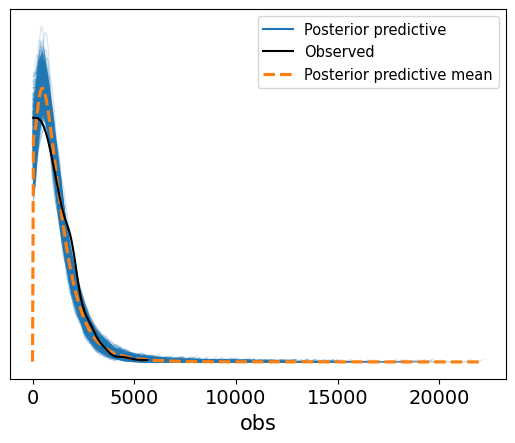

In [40]:
with model:
    ppc = pm.sample_posterior_predictive(trace)

az.plot_ppc(ppc)

# Poisson model (VIRKER IKKE)

Valgte eksponential fordelingen for a og b, fordi $a,b>0$ og flere dage i cirkulation og flere antal vaske øger slid på tøjet.

Så for at vælge de korrekte parametre finder vi middelværdien af dage og vaske i dataen

In [2]:
#mean af eksponential
mean_dage = samlet_df['Dage i cirkulation'].mean()
mean_vask = samlet_df['Total antal vask'].mean()

mean_dage, mean_vask

(np.float64(1092.732440903484), np.float64(31.01294966938305))

In [3]:
mean_dage/mean_vask

np.float64(35.2347149352989)

Det ses at disse means er på forskellige skalaer, 1092:31. Dette tager vi højde for, så både dage og vask bidrager lige meget til p(kass). 

Eftersom middelværdien for eksponentialfordelingen er $mean=\frac{1}{λ}$, gælder det at $\lambda=\frac{1}{mean}$. Vi vælger λ ud fra data dermed:

$$\lambda_a=mean\_dage,\quad\lambda_b=mean\_vask$$

Fordi så er $a⋅mean\_dage≈b⋅mean\_vask≈1$ så begge variable bidrager lige meget til p(kass).

In [4]:
b = 1 /mean_vask
a = (b*mean_vask)/mean_dage
a, b

(np.float64(0.0009151371027048379), np.float64(0.032244594940520316))

Tjekker at ovenstående ligning holder

In [5]:
np.isclose(a*mean_dage, b*mean_vask)

np.True_

kan dermed opstille priors:
$$a \sim \exp(\lambda_a = mean\_dage), \quad b\sim \exp(\lambda_b = mean\_vask)$$
Vi vælger Poisson som likelihood fordi vi modellerer kassering som en rate-proces — tøj akkumulerer slid over tid via dage og vaske indtil kassering indtræffer. Alle observationer er kasserede (event = 1), så vi sætter observed = 1 for alle rækker. Modellen lærer a og b så λ = a·dage + b·vask ≈ 1, hvilket svarer til at kasseringsraten passer med de observerede data.

Dermed bliver modellen

In [ ]:
#rækker hvor dage=0 eller vask=0 giver lam=0, hvilket er ugyldigt for Poisson
mask = (samlet_df['Dage i cirkulation'] == 0) | (samlet_df['Total antal vask'] == 0)
print(mask.sum(), 'ud af', len(samlet_df))

#fjerner dem fra df
samlet_df_filtered = samlet_df[~mask]

#sample en delmængde af dataen mens modellen udvikles
samlet_df_sample = samlet_df_filtered.sample(n=1000, random_state = 42)

21535 ud af 247265


In [7]:
with pm.Model() as model:
    #priors for a og b
    a = pm.Exponential('a', lam = mean_dage)
    b = pm.Exponential('b', lam= mean_vask)
    
    #lineær kombination hvor det rigtige data bruges
    lam = a * samlet_df_sample['Dage i cirkulation'] + b * samlet_df_sample['Total antal vask']

    # likelihood funktionen
    obs = pm.Poisson('obs', mu = lam, observed = np.ones_like(samlet_df_sample['Dage i cirkulation']))

    #resultatet
    trace = pm.sample(draws=500, tune=500, chains=2)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [a, b]


Output()

Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 288 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


In [ ]:

az.summary(trace)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,0.001,0.000,0.001,0.001,0.0,0.0,272.0,485.0,1.00
b,0.005,0.001,0.003,0.007,0.0,0.0,246.0,397.0,1.01


In [10]:
a_posterior = 0.001 
b_posterior = 0.005

Ved så at se på de to led i p(kass) kan jeg se deres bidrag til kassation.

In [11]:
bidrag_dage = a_posterior * mean_dage
bidrag_vask = b_posterior * mean_vask
bidrag_dage, bidrag_vask

(np.float64(1.0927324409034842), np.float64(0.15506474834691525))

Da bidraget for dage er meget større end for vask betyder det, at tid i cirkulation er en stærkere driver for kassering end antal vaske

Simulerer nu nyt data ud fra min posterior

pm.sample_posterior_predictive(trace):

- Tager mine samplede værdier af a og b fra trace og bruger dem til at simulere nye observationer via min model. For hvert sample af (a, b) beregnes $\lambda = a\cdot dage + b\cdot vask$ og der samples fra Poisson($\lambda$).
Resultatet er et datasæt af simulerede kasseringer.

Posterior predictive check bruges til at validere modellen ved at sammenligne simulerede data med observerede data. Vi sampler fra posterioren for at afspejle usikkerheden på a og b, frem for blot at bruge deres middelværdier. 

In [ ]:
with model:
    ppc = pm.sample_posterior_predictive(trace)

#henter de simulerede værdier og beregner mean og std. afvigelse
print(ppc.posterior_predictive['obs'].values.mean())
print(ppc.posterior_predictive['obs'].values.std()) 

Sampling: [obs]


Output()

1.001447
1.2513292557081048


<Axes: xlabel='obs'>

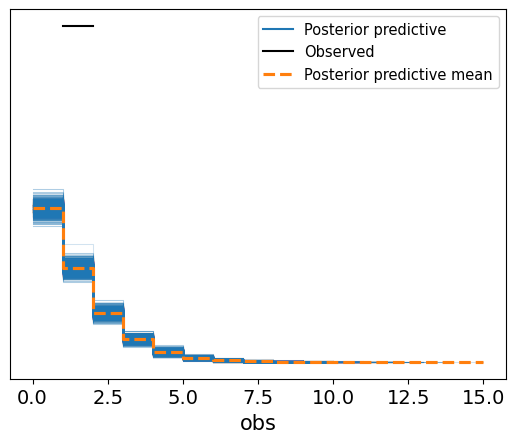

In [15]:
az.plot_ppc(ppc)